### In this guide, we'll clean a real, publicly available dataset - the New York City Airbnb Open Data from Kaggle - step by step using the Pandas library. It's a large, realistically messy dataset with missing reviews, inconsistent text, price outliers (including listings priced at $0), and mixed data types, making it a great example for learning data cleaning.

In [1]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

### dirty data distorts analysis, leading to wrong insights, inaccurate predictions, and bad business decisions. The most common issues are:
1. Missing values
2. Duplicate entries
3. Incorrect data types
4. Inconsistent formatting
5. Outliers that skew results
###Fixing these ensures accuracy, consistency, and reliability before a single chart or model ever touches your data.

### Download AB_NYC_2019.csv from [Kaggle's New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data?ref=datatodeploy.com$0) page and place it in your working directory. It contains roughly 49,000 Airbnb listings across NYC's five boroughs, with columns for host information, location, price, room type, reviews, and availability.



In [2]:
file_path = "AB_NYC_2019.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "dgomonov/new-york-city-airbnb-open-data", file_path,)

df.head()

/tmp/ipykernel_3174/2234945588.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "dgomonov/new-york-city-airbnb-open-data", file_path,)


100%|██████████| 2.29M/2.29M [00:01<00:00, 1.95MB/s]

Extracting zip of AB_NYC_2019.csv...


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Before cleaning anything, take a moment to understand what you're working with. Skipping this step is how people end up "fixing" columns that didn't need it and missing the ones that did.

In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Already, df.info() tells you exactly where the missing-data problem lives: last_review and reviews_per_month are each missing over 10,000 values, while name and host_name are only missing a small number.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


### df.describe() also highlights potential outliers; take a look at price and minimum_nights, both of which have extreme values in this dataset.

### .T is the transpose operator in Pandas (and NumPy) — it flips a DataFrame so rows become columns and columns become rows.

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## **Handling Missing Data**

In [7]:
# Total missing values per column
print(df.isnull().sum())


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [8]:
# Percentage missing, which is often more useful than raw counts
print((df.isnull().sum() / len(df) * 100).round(2))

id                                 0.00
name                               0.03
host_id                            0.00
host_name                          0.04
neighbourhood_group                0.00
neighbourhood                      0.00
latitude                           0.00
longitude                          0.00
room_type                          0.00
price                              0.00
minimum_nights                     0.00
number_of_reviews                  0.00
last_review                       20.56
reviews_per_month                 20.56
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64


### **last_review** and **reviews_per_month** are missing together for the same rows, which makes sense: a listing with zero reviews has no "reviews per month" to calculate.

## **Deciding: Remove or Fill?**

### There's no single right approach here. It depends on how the missing value affects your analysis.
### Drop rows only when missingness is insignificant and unrelated to your goals:
### name and host_name are missing for only a few of rows out of ~49,000 , we can drop them without losing much of data

In [9]:
df = df.dropna(subset=['name', 'host_name'])

In [10]:
df.shape # 40 lines dropped from dataset

(48858, 16)

### Fill when there's a clear, logical default. For example, in this case, no reviews means zero reviews per month, not an unknown value:

In [11]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = df['last_review'].fillna(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48858 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48858 non-null  int64  
 1   name                            48858 non-null  object 
 2   host_id                         48858 non-null  int64  
 3   host_name                       48858 non-null  object 
 4   neighbourhood_group             48858 non-null  object 
 5   neighbourhood                   48858 non-null  object 
 6   latitude                        48858 non-null  float64
 7   longitude                       48858 non-null  float64
 8   room_type                       48858 non-null  object 
 9   price                           48858 non-null  int64  
 10  minimum_nights                  48858 non-null  int64  
 11  number_of_reviews               48858 non-null  int64  
 12  last_review                     48858

### For last_review, a missing date isn't something you should fake. Instead of filling it with a placeholder date - which would corrupt any time-based analysis - it's often better to leave it as NaT (Pandas' null timestamp) and filter it out whenever a specific analysis requires a real date:

In [13]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [14]:
df['last_review']

,last_review
0,2018-10-19
1,2019-05-21
2,NaT
3,2019-07-05
4,2018-11-19
...,...
48890,NaT
48891,NaT
48892,NaT
48893,NaT


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48858 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48858 non-null  int64         
 1   name                            48858 non-null  object        
 2   host_id                         48858 non-null  int64         
 3   host_name                       48858 non-null  object        
 4   neighbourhood_group             48858 non-null  object        
 5   neighbourhood                   48858 non-null  object        
 6   latitude                        48858 non-null  float64       
 7   longitude                       48858 non-null  float64       
 8   room_type                       48858 non-null  object        
 9   price                           48858 non-null  int64         
 10  minimum_nights                  48858 non-null  int64         
 11  number_

## **Removing Duplicates**

### Duplicates often appear in datasets that are scraped or exported multiple times, and they quietly inflate counts and averages.

### The original dataset doesn't contain duplicate listings, so we'll intentionally introduce a few to demonstrate how duplicate detection works in practice.

In [16]:
duplicate_rows = df.sample(n=500, random_state=42)

df = pd.concat([df, duplicate_rows], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New shape: {df.shape}")
print(f"Duplicate IDs: {df['id'].duplicated().sum()}")

New shape: (49358, 16)
Duplicate IDs: 500


## **Detecting Duplicates**

In [17]:
duplicates = df[df.duplicated()]
print(f"Found {len(duplicates)} fully duplicated rows")


Found 500 fully duplicated rows


### In this dataset, id is a unique listing identifier, so a more meaningful duplicate check is whether the same ID appears more than once - which shouldn't happen and is worth verifying explicitly:

In [18]:
print(f"Duplicate listing IDs: {df['id'].duplicated().sum()}")


Duplicate listing IDs: 500


## **Removing Duplicates**

In [19]:
df = df.drop_duplicates()

In [20]:
df.shape

(48858, 16)

### Sometimes duplicates exist only across specific columns, not the whole row. For example, the same host listing near-identical rooms. You can target that directly:

In [21]:
target_host_id = df['host_id'].iloc[0]  # lock this in before anything else changes
target_lat = df['latitude'].iloc[0]
target_lon = df['longitude'].iloc[0]

partial_dupes = df.sample(n=500, random_state=7).copy()
partial_dupes['host_id'] = target_host_id
partial_dupes['latitude'] = target_lat
partial_dupes['longitude'] = target_lon

df = pd.concat([df, partial_dupes], ignore_index=True)
df = df.sample(frac=1, random_state=7).reset_index(drop=True)

print(f"Full-row duplicates: {df.duplicated().sum()}")
print(f"Rows sharing this host_id: {(df['host_id'] == target_host_id).sum()}")

Full-row duplicates: 0
Rows sharing this host_id: 501


In [22]:
df_possible_dupes = df[df.duplicated(subset=['host_id', 'latitude', 'longitude'], keep=False)]


In [23]:
df_possible_dupes.shape

(504, 16)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49358 entries, 0 to 49357
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              49358 non-null  int64         
 1   name                            49358 non-null  object        
 2   host_id                         49358 non-null  int64         
 3   host_name                       49358 non-null  object        
 4   neighbourhood_group             49358 non-null  object        
 5   neighbourhood                   49358 non-null  object        
 6   latitude                        49358 non-null  float64       
 7   longitude                       49358 non-null  float64       
 8   room_type                       49358 non-null  object        
 9   price                           49358 non-null  int64         
 10  minimum_nights                  49358 non-null  int64         
 11  nu

## **Fixing Incorrect Data Types**
### Pandas guesses data types when it loads a dataset, and it doesn't always guess correctly, especially for dates.

In [25]:
print(df.dtypes)


id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object


## **Convert Types**
### Coverting **last_review** column to datetime
### Coverting **price** column to numeric for example int64, if some values comes with '$' or ','

In [26]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df['price'] = pd.to_numeric(df['price'], errors='coerce')


### Converting last_review to a real datetime is what makes .dt.year, .dt.month, and date-range filtering possible later. Trying to do date arithmetic on a string column is a common and confusing source of bugs.

## **Fixing Inconsistent Formatting**
### Text columns are where inconsistency hides. Even when the underlying value is the same, differences in casing or spacing are treated by Pandas as entirely separate categories.

In [27]:
df['neighbourhood'] = df['neighbourhood'].str.strip()

df['neighbourhood'] = df['neighbourhood'].str.title()

print(df['room_type'].unique())
print(df['neighbourhood_group'].unique())


['Private room' 'Entire home/apt' 'Shared room']
['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']


### If you find near-duplicate categories - a common real-world issue, even though this particular dataset is already fairly clean on room_type - fix them explicitly:

In [28]:
df['neighbourhood_group'] = df['neighbourhood_group'].replace({
    'brooklyn': 'Brooklyn',
    'Manhatan ': 'Manhattan'
})


## **Dealing with Outliers**
### This dataset has two well-known outlier issues: some listings are priced at $0 (obviously not a real price), and minimum_nights includes extreme values like over 1,000 nights minimum required for a stay, which is not a realistic booking.
### **Spotting Outliers**

In [29]:
print(df['price'].describe())
print(df['minimum_nights'].describe())

zero_price = df[df['price'] == 0]
print(f"Listings priced at $0: {len(zero_price)}")


count    49358.000000
mean       152.753434
std        240.983739
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64
count    49358.000000
mean         6.998015
std         19.936852
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64
Listings priced at $0: 11


### **Using IQR to Detect Outliers Systematically**

In [30]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Price outliers by IQR: {len(price_outliers)}")


Price outliers by IQR: 3000


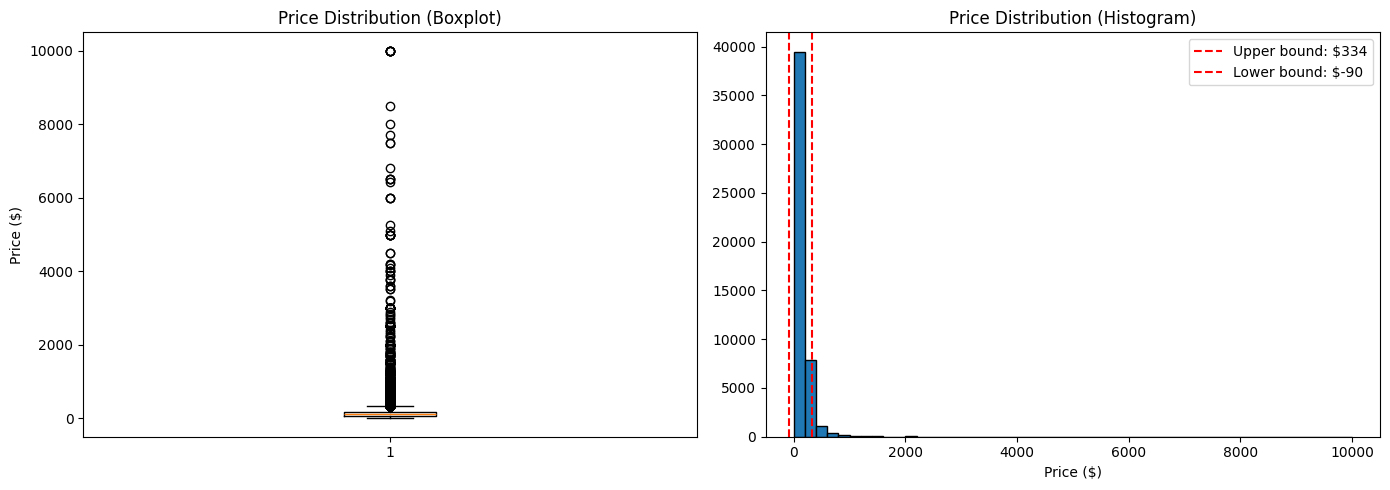

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: shows the IQR box, whiskers, and outlier points directly
axes[0].boxplot(df['price'], vert=True)
axes[0].set_title('Price Distribution (Boxplot)')
axes[0].set_ylabel('Price ($)')

# Histogram: shows the full shape, with IQR bounds marked as reference lines
axes[1].hist(df['price'], bins=50, edgecolor='black')
axes[1].axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound: ${upper_bound:.0f}')
axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound: ${lower_bound:.0f}')
axes[1].set_title('Price Distribution (Histogram)')
axes[1].set_xlabel('Price ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_outliers.png', dpi=150)
plt.show()

Minimum nights outliers by IQR: 6666


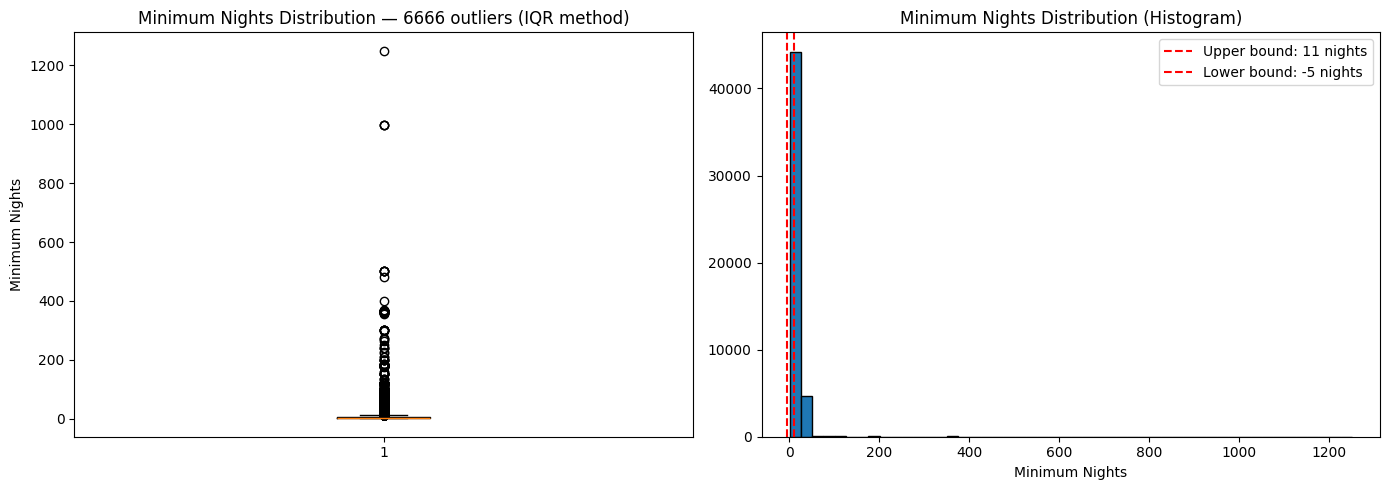

In [32]:
Q1_nights = df['minimum_nights'].quantile(0.25)
Q3_nights = df['minimum_nights'].quantile(0.75)
IQR_nights = Q3_nights - Q1_nights

lower_bound_nights = Q1_nights - 1.5 * IQR_nights
upper_bound_nights = Q3_nights + 1.5 * IQR_nights

nights_outliers = df[(df['minimum_nights'] < lower_bound_nights) | (df['minimum_nights'] > upper_bound_nights)]
print(f"Minimum nights outliers by IQR: {len(nights_outliers)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['minimum_nights'], vert=True)
axes[0].set_title(f'Minimum Nights Distribution — {len(nights_outliers)} outliers (IQR method)')
axes[0].set_ylabel('Minimum Nights')

# Histogram with IQR bounds marked
axes[1].hist(df['minimum_nights'], bins=50, edgecolor='black')
axes[1].axvline(upper_bound_nights, color='red', linestyle='--', label=f'Upper bound: {upper_bound_nights:.0f} nights')
axes[1].axvline(lower_bound_nights, color='red', linestyle='--', label=f'Lower bound: {lower_bound_nights:.0f} nights')
axes[1].set_title('Minimum Nights Distribution (Histogram)')
axes[1].set_xlabel('Minimum Nights')
axes[1].legend()

plt.tight_layout()
plt.savefig('minimum_nights_outliers.png', dpi=150)
plt.show()

### **Handling Outliers**

In [29]:
df = df[df['price'] > 0]

df = df[df['minimum_nights'] <= 365]


In [30]:
df.shape

(49334, 16)

### Removing outliers isn't always the right move, especially in financial or experimental data, where an extreme value might be the whole point of the analysis. In this dataset, a $0 price and a 1,250-night minimum stay are clearly meaningless, but always ask yourself why an outlier exists before deciding whether to remove it or leave it in.

## **String Manipulation**
### Listing names in this dataset are free text and highly inconsistent, with a mix of casing, emojis, and special characters.
### **Cleaning Free-Text Columns**
### Both lines use regex character classes to find and remove specific kinds of characters. Here's each one broken down piece by piece.
### 1. Remove characters that aren't letters, numbers, or spaces
### Example: "Cozy Studio!! ★ Near Subway 🚇" → "Cozy Studio Near Subway "
### 2. Collapse repeated whitespace left behind by the character removal
### when you delete "!!" out of "Studio!! ★ Near", you're often left with double spaces ("Studio  Near") where the removed characters used to be. \s+ cleans that up.

In [31]:
df['name'] = df['name'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)

df['name'] = df['name'].str.replace(r'\s+', ' ', regex=True).str.strip()


### **Extracting Structure from Free Text**
### Sometimes a messy text column actually contains structured information worth pulling out. Here, room_type is already its own column, but you can still derive useful features from name. For example, flagging listings that advertise being close to the subway:

In [32]:
df['mentions_subway'] = df['name'].str.contains('subway', case=False, na=False)
print(df['mentions_subway'].value_counts())


mentions_subway
False    48219
True      1115
Name: count, dtype: int64


## **Validate the Cleaned Data**
### Before you consider the dataset done, re-run the same checks from Step 1 and compare.



In [33]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())


(49334, 17)
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10113
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
mentions_subway                       0
dtype: int64
                 id       host_id      latitude     longitude         price  \
count  4.933400e+04  4.933400e+04  49334.000000  49334.000000  49334.000000   
mean   1.902551e+07  6.761923e+07     40.728840    -73.952737    152.796814   
min    2.539000e+03  2.438000e+03     40.499790    -74.244

### Here we have 49,334 rows because we added 500 samples to the dataset. After converting last_review values from 0 to NaT, pandas now counts them as missing values - if we had kept them as 0, we would have no missing values in that column.

## ***Save the Cleaned Dataset***

In [39]:
df.to_csv('AB_NYC_2019_cleaned.csv', index=False)

### Keeping the cleaned file separate from the original raw download means you can always look back to the original dataset and re-run your cleaning steps if you change your mind about any of them.